<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/CL_ResNet18(with_augmentation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Centralized Baseline | Tomato

**Dataset Download**

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
# !kaggle datasets download -d saniyaverma914/cropdg-unified-multidomain

In [3]:
# !unzip cropdg-unified-multidomain.zip

Imports and Setup

In [4]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import copy

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Paths

In [5]:
BASE_DIR = "/content"
PV_TOMATO = os.path.join(BASE_DIR, "PV", "Tomato")
CCMT_TOMATO = os.path.join(BASE_DIR, "CCMT", "Tomato")
PD_TOMATO = os.path.join(BASE_DIR, "PD", "Tomato")

Build Dataset Metadata

In [6]:
def collect_samples(root_dir):
    samples = []
    classes = sorted(os.listdir(root_dir))

    for label, cls in enumerate(classes):
        class_path = os.path.join(root_dir, cls)
        if not os.path.isdir(class_path):
            continue

        for img in os.listdir(class_path):
            samples.append({
                "path": os.path.join(class_path, img),
                "label": label,
                "class_name": cls
            })

    return samples, classes

pv_samples, class_names = collect_samples(PV_TOMATO)
ccmt_samples, _ = collect_samples(CCMT_TOMATO)

train_samples = pv_samples + ccmt_samples

print("Total Train Samples:", len(train_samples))
print("Classes:", class_names)

Total Train Samples: 37432
Classes: ['Blight', 'Healthy', 'Leaf_spot', 'Viral']


Train/Validation Split

In [7]:
labels = [s["label"] for s in train_samples]

train_idx, val_idx = train_test_split(
    range(len(train_samples)),
    test_size=0.15,
    stratify=labels,
    random_state=42
)

train_data = [train_samples[i] for i in train_idx]
val_data = [train_samples[i] for i in val_idx]

print("Train:", len(train_data))
print("Val:", len(val_data))

Train: 31817
Val: 5615


PD Test Set (Unseen Domain)

In [8]:
test_data, _ = collect_samples(PD_TOMATO)
print("Unseen Test Samples:", len(test_data))

Unseen Test Samples: 640


Dataset Class

In [9]:
class CropDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample["path"]).convert("RGB")
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

Transforms

In [10]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.4,0.4,0.4,0.05),
    transforms.GaussianBlur(kernel_size=3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

DataLoaders

In [11]:
batch_size = 32

train_loader = DataLoader(
    CropDataset(train_data, train_transform),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    CropDataset(val_data, test_transform),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    CropDataset(test_data, test_transform),
    batch_size=batch_size,
    shuffle=False
)

Class-weighted loss

In [12]:
label_list = [s["label"] for s in train_data]
counts = Counter(label_list)

total = len(train_data)
num_classes = len(class_names)

weights = [total / (num_classes * counts[i]) for i in range(num_classes)]
weights = torch.tensor(weights).float().to(device)

print("Class counts:", counts)

Class counts: Counter({2: 13269, 0: 8005, 3: 7065, 1: 3478})


Model (Full fine-tuning)

In [13]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=25
)

Training

In [14]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

num_epochs = 15
best_val_acc = 0
patience = 5
counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    avg_loss = running_loss / len(train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f} | Val Acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered.")
        break

100%|██████████| 995/995 [08:10<00:00,  2.03it/s]


Epoch 1: Loss=0.7967 | Val Acc=0.8470


100%|██████████| 995/995 [08:00<00:00,  2.07it/s]


Epoch 2: Loss=0.7021 | Val Acc=0.8721


100%|██████████| 995/995 [07:57<00:00,  2.08it/s]


...

Epoch 13: Loss=0.5144 | Val Acc=0.9635


100%|██████████| 995/995 [08:01<00:00,  2.07it/s]


Epoch 14: Loss=0.5039 | Val Acc=0.9676


100%|██████████| 995/995 [08:03<00:00,  2.06it/s]


Epoch 15: Loss=0.4999 | Val Acc=0.9687


Final evaluation on PD

In [15]:
model.load_state_dict(best_model)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report (PD - Unseen Domain):\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report (PD - Unseen Domain):

              precision    recall  f1-score   support

      Blight       0.46      0.66      0.54       194
     Healthy       0.57      0.26      0.36        62
   Leaf_spot       0.57      0.51      0.54       255
       Viral       0.54      0.43      0.48       129

    accuracy                           0.51       640
   macro avg       0.53      0.46      0.48       640
weighted avg       0.53      0.51      0.51       640



Confusion matrix

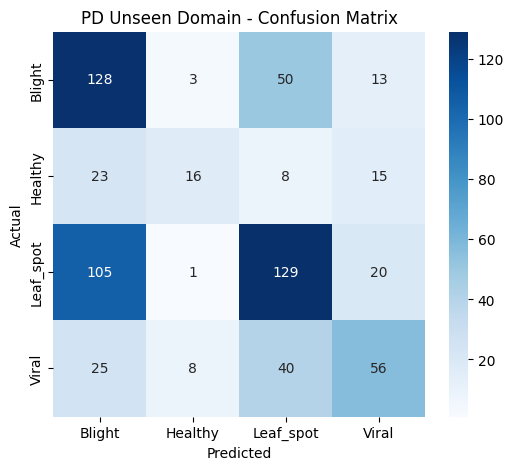

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title("PD Unseen Domain - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()